In [8]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

In [9]:
# Filter the DataFrame for Data Analyst jobs in India
df_DA_India = df[df['job_title'].str.contains('Data Analyst', case=False, na=False) & (df['job_country'] == 'India')]

# Extract the month of the job posting
df_DA_India['job_posted_month_no'] = df_DA_India['job_posted_date'].dt.month

# Explode the job_skills column to count the frequency of each skill
df_exploded = df_DA_India.explode('job_skills')

# Create a pivot table to count the frequency of each skill by month
df_pivot = df_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# Sorting the skills in descending order based on the total count across all months
df_pivot.loc['Total'] = df_pivot.sum()
df_pivot = df_pivot[df_pivot.loc['Total'].sort_values(ascending=False).index]
df_pivot = df_pivot.drop('Total')

# Calculate the total number of job postings for each month to compute the percentage of each skill requirement
DA_total = df_DA_India.groupby('job_posted_month_no').size()
df_pivot_percent = df_pivot.div(DA_total/100, axis=0)

# Changing the month numbers to month names for better readability in the plot
df_pivot_percent = df_pivot_percent.reset_index()
df_pivot_percent['job_posted_month'] = df_pivot_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(str(x), format='%m').strftime('%B'))
df_pivot_percent = df_pivot_percent.set_index('job_posted_month')
df_pivot_percent = df_pivot_percent.drop(columns='job_posted_month_no') # Drop the month number column as it's no longer needed

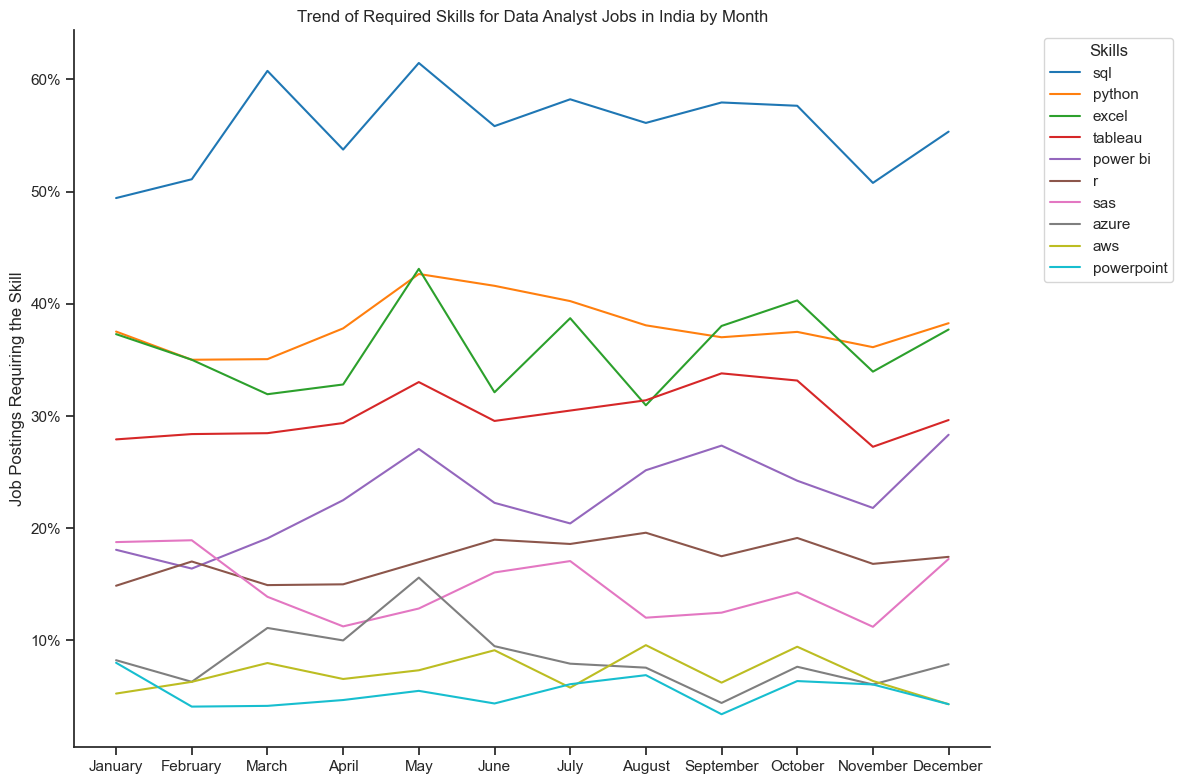

In [12]:
# Plotting the trend of required skills for Data Analyst jobs in India by month
plt.figure(figsize=(12, 8))

df_plot = df_pivot_percent.iloc[:, :10]  # Plot only the top 10 skills
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style="ticks")
sns.despine()  # Use a color palette with 10 distinct colors

plt.title('Trend of Required Skills for Data Analyst Jobs in India by Month')
plt.xlabel('')
plt.ylabel('Job Postings Requiring the Skill')
plt.legend(title='Skills', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(PercentFormatter())  # Format y-axis as percentages
plt.tight_layout()
plt.show()